In [ ]:
import marimo as mo

from utils import barh, chat_dirs, columns, connect, group_name, note

# Caracteres invisibles que mete WhatsApp. Las celdas SQL de marimo son f-strings, así
# que se interpolan como {LRM}, {NNBSP}... en vez de escribir escapes en el SQL.
LRM = "\u200e"  # left-to-right mark
NNBSP = "\u202f"  # narrow no-break space
FSI = "\u2068"  # first strong isolate: abre el nombre en una mención
PDI = "\u2069"

# EDA bronze: el chat tal como lo exporta WhatsApp

Este notebook mira los datos crudos (`data/raw/<chat>/`) antes de transformarlos: qué
trae la exportación, cómo está estructurado el texto, qué rarezas tiene y, al final,
**qué conservamos y qué descartamos**. Esa última tabla es la especificación del job de
anonimización, que convierte el texto crudo en una tabla de mensajes.

**Privacidad.** El chat es privado y este notebook se publica en GitHub, así que aquí
nunca aparece un nombre real ni texto libre de un mensaje: los remitentes se muestran
con `anon(nombre)`, un hash con sal secreta, y de los mensajes de texto solo se
muestran conteos y longitudes. La anonimización completa del contenido es trabajo del
job, no de este notebook.

Trabaja sobre el chat activo (`chat` en `params.yml`, o `CHAT=<slug>` al exportar).

**Nota sobre el SQL.** Las celdas SQL de marimo se guardan como f-strings, así que las
expresiones regulares evitan `\` y llaves: `[0-9]` en vez de `\d`, `[.]` en vez de
`\.`, `[[]` y `[]]` para los corchetes, y los caracteres invisibles se interpolan como
`{LRM}`, `{NNBSP}`, `{FSI}` y `{PDI}` (definidos al inicio del notebook).

In [ ]:
dirs = chat_dirs()
group = group_name()
# Sin vistas de interim/: este notebook arma su propia tabla `bronze` a partir del
# texto crudo, y al final la compara con la que produce el job.
con = connect(views=False)
# El grupo mismo aparece como remitente de algunos avisos; lo comparamos en SQL.
con.execute("SET VARIABLE grupo = ?", [group])
note(f"Chat activo: **{dirs['chat']}** (`data/raw/{dirs['chat']}/`)")

Chat activo: baketon_city ( data/raw/baketon_city/ )

## 1. La fuente

El job de ingesta (`make ingest`) copia el zip exportado a `data/raw/<chat>/`, lo
descomprime y escribe `FUENTE.txt` con el origen, las fechas, la descripción del
formato y el sha256 de cada archivo. Aquí se muestra con el nombre del grupo oculto.

In [ ]:
_fuente = (dirs["raw"] / "FUENTE.txt").read_text(encoding="utf-8")
mo.plain_text(_fuente.replace(group, "«grupo»"))

Exportación del grupo de WhatsApp "«grupo»"
Chat en el proyecto: baketon_city (carpetas data/*/baketon_city/)
Fuente: WhatsApp (Meta Platforms, Inc.) (https://www.whatsapp.com)
Obtención: Exportación manual desde la app de WhatsApp para iOS: Info del grupo → Exportar chat → Sin archivos (solo el texto, sin fotos, audios ni stickers).
Archivo original: WhatsApp Chat - «grupo».zip
Exportado: 2026-09-18 17:37 (hora local del celular, según el zip)
Periodo: 2024-09-28 a 2026-09-18 (259,014 mensajes y avisos del sistema)
Zona horaria de los mensajes: America/Hermosillo (hora local, sin offset)

Descripción
 Historial completo del grupo, exportado por WhatsApp como texto plano. El zip trae un
 solo archivo, _chat.txt (UTF-8, fin de línea CRLF), con una línea por mensaje en el
 formato "[dd/mm/aa, h:mm:ss a.m.] Remitente: texto"; los mensajes de varias líneas
 siguen en las líneas de abajo, sin encabezado. La hora es la hora local del celular
 que exportó, en formato de 12 horas y sin zona horaria; entre la hora y "a.m."/"p.m."
 va un espacio angosto (U+202F). WhatsApp agrega caracteres invisibles: una marca de
 dirección (U+200E) al inicio de líneas con adjuntos o avisos, y aislantes
 (U+2068…U+2069) alrededor de las menciones "@Nombre". Los contactos que el celular no
 tiene guardados aparecen como "~ Nombre". Como se exportó sin archivos, cada adjunto
 se sustituye por un marcador en inglés ("sticker omitted", "image omitted", "audio
 omitted", "video omitted", "GIF omitted", "document omitted", "card omitted"), a veces
 después del pie de foto. También hay avisos del sistema (altas y bajas, mensajes
 eliminados, cambios de descripción, mensajes de una sola vista, encuestas "POLL:") y
 el sufijo "<This message was edited>" en los mensajes editados. Los mensajes no
 siempre están en orden cronológico estricto (p. ej. al fijar un mensaje).

Documentación
 - https://faq.whatsapp.com/1180414079177245/

Uso
 Datos privados de los participantes del grupo, usados solo con fines académicos. No se
 redistribuyen: data/ no se versiona en git y todo conjunto derivado se anonimiza.

Archivos (fecha según la fecha del archivo, UTC)
 whatsapp_chat.zip 4.6 MB 2026-09-19 00:37 sha256 0b69c754a96c243f0b5856f5be480ad9fa7b55b3b60fa2a41dbeb1b482dac0ec
 _chat.txt 18.0 MB 2026-09-19 00:37 sha256 a06661ec7f0fd26b6d634b565dfa860d3da11287bcd47b9d5cd564615794ba73

Generado por ingest_job el 2026-09-21 16:40 UTC

## 2. El archivo

`_chat.txt` es texto plano. DuckDB lo lee completo con `read_text`, que además
falla si el archivo no es UTF-8 válido. Contamos los fines de línea para saber cómo
separar los mensajes:

In [ ]:
chat_file = str(dirs["raw"] / "_chat.txt")

In [ ]:
line_endings = mo.sql(
    f"""
    WITH t AS (SELECT content FROM read_text('{chat_file}')),
    counts AS (
        SELECT
            length(content) AS caracteres,
            starts_with(content, chr(65279)) AS tiene_bom,
            (length(content) - length(replace(content, chr(13) || chr(10), ''))) // 2 AS crlf,
            length(content) - length(replace(content, chr(10), '')) AS lf_total,
            length(content) - length(replace(content, chr(13), '')) AS cr_total
        FROM t
    )
    SELECT caracteres, tiene_bom, crlf, lf_total - crlf AS lf_sin_cr, cr_total - crlf AS cr_sin_lf
    FROM counts
    """,
    engine=con
)

caracteres,tiene_bom,crlf,lf_sin_cr,cr_sin_lf
16930328,false,259014,6388,1


El archivo usa dos fines de línea distintos: **CRLF** (`\r\n`) cierra cada mensaje y
**LF** solo (`\n`) es un salto de línea *dentro* de un mensaje. Por eso no conviene
leerlo línea por línea: un mensaje de varias líneas se partiría y sus líneas de
continuación no tendrían fecha ni remitente. Separando por CRLF, cada registro es
exactamente un mensaje completo. Así se arma `raw_records`, una fila por registro con
su posición en el archivo:

In [ ]:
_ = mo.sql(
    f"""
    CREATE OR REPLACE TABLE raw_records AS
    WITH t AS (
        SELECT string_split(content, chr(13) || chr(10)) AS records
        FROM read_text('{chat_file}')
    )
    SELECT i AS record_no, records[i] AS record
    FROM t, range(1, len(records) + 1) AS r(i)
    """,
    engine=con
)

## 3. Registros y encabezado

Cada registro empieza con un encabezado:

```
[28/09/24, 2:31:21 p.m.] ~ Nombre Apellido: texto del mensaje
```

- `[dd/mm/aa, h:mm:ss a.m.]`: fecha y hora de 12 horas, en hora local y sin zona
  horaria. Entre la hora y `a.m.`/`p.m.` va un espacio angosto (U+202F), no un espacio
  normal.
- Antes del corchete puede ir una marca invisible U+200E, solo en adjuntos y avisos.
- `~ Nombre Apellido`: el remitente. La `~` (seguida de U+202F) indica un contacto que
  el celular no tiene guardado.
- `: texto`: el cuerpo, que puede traer saltos de línea `\n` si el mensaje tiene varias
  líneas.

Con expresiones regulares en SQL separamos encabezado, remitente y cuerpo, convertimos
la fecha y hora a timestamp y clasificamos cada cuerpo en un tipo de registro. La
tabla `bronze` vive solo en la memoria de este notebook.

In [ ]:
_ = mo.sql(
    f"""
    CREATE OR REPLACE TABLE bronze AS
    WITH parts AS (
        SELECT
            record_no,
            starts_with(record, '{LRM}') AS lrm_prefix,
            -- "[28/09/24, 2:31:21 p.m.] " -> "28/09/24, 2:31:21 p.m."
            regexp_extract(record, '^{LRM}?[[]([^]]*)[]] ', 1) AS header,
            -- todo lo que va entre "] " y el primer ":" es el remitente
            regexp_extract(record, '^[^]]*[]] ([^:]+?):( |$)', 1) AS sender,
            regexp_replace(record, '^[^]]*[]] [^:]+?:( |$)', '') AS body
        FROM raw_records
        WHERE record <> ''
    ),
    parsed AS (
        SELECT
            *,
            try_strptime(
                replace(replace(replace(header, '{NNBSP}', ' '), 'a.m.', 'AM'), 'p.m.', 'PM'),
                '%d/%m/%y, %I:%M:%S %p'
            ) AS ts
        FROM parts
    )
    SELECT
        *,
        CASE
            WHEN sender = getvariable('grupo') THEN 'group_notice'
            WHEN body = '' THEN 'empty'
            WHEN regexp_matches(body, '{LRM}[A-Za-z ]+ omitted') THEN 'attachment'
            WHEN regexp_matches(body, '^{LRM}?POLL:') THEN 'poll'
            WHEN starts_with(body, '{LRM}Location: ') THEN 'location'
            WHEN starts_with(body, '{LRM}You received a view once') THEN 'view_once'
            WHEN regexp_matches(body, '^{LRM}(This message was deleted|You deleted this message)')
                THEN 'deleted'
            WHEN regexp_matches(body, '^{LRM}(Waiting for this message|This message can.t be displayed)')
                THEN 'unavailable'
            WHEN starts_with(body, '{LRM}') THEN 'system_notice'
            ELSE 'text'
        END AS kind
    FROM parsed
    """,
    engine=con
)

In [ ]:
header_check = mo.sql(
    f"""
    SELECT
        (SELECT count(*) FROM raw_records) AS registros,
        (SELECT count(*) FROM raw_records WHERE record = '') AS registros_vacios,
        count(*) FILTER (header <> '') AS con_encabezado,
        count(*) FILTER (contains(header, '{NNBSP}')) AS hora_con_u202f,
        count(*) FILTER (ts IS NULL) AS fecha_no_leida,
        count(*) FILTER (sender = '') AS sin_remitente,
        count(*) FILTER (lrm_prefix) AS con_marca_u200e
    FROM bronze
    """,
    engine=con
)

registros,registros_vacios,con_encabezado,hora_con_u202f,fecha_no_leida,sin_remitente,con_marca_u200e
259015,1,259014,259014,0,0,29522


Todos los registros no vacíos tienen encabezado, fecha legible y remitente. El único
registro vacío es el final del archivo, que termina en CRLF. Un ejemplo de cada tipo,
con el remitente anonimizado y sin mostrar texto libre:

In [ ]:
examples = mo.sql(
    f"""
    SELECT
        record_no AS registro,
        ts AS fecha_hora,
        anon(sender) AS remitente,
        lrm_prefix AS marca_u200e,
        kind AS tipo,
        CASE
            WHEN kind = 'attachment' THEN
                regexp_extract(body, '{LRM}([A-Za-z ]+ omitted)', 1)
                || CASE WHEN starts_with(body, '{LRM}') THEN '' ELSE ' (con pie de foto)' END
            WHEN kind IN ('view_once', 'unavailable') THEN replace(body, '{LRM}', '')
            WHEN kind = 'deleted' THEN regexp_replace(replace(body, '{LRM}', ''), 'by admin .*', 'by admin <nombre>.')
            ELSE '<' || length(body) || ' caracteres>'
        END AS cuerpo
    FROM bronze
    QUALIFY row_number() OVER (PARTITION BY kind ORDER BY record_no) = 1
    ORDER BY record_no
    """,
    engine=con
)

registro,fecha_hora,remitente,marca_u200e,tipo,cuerpo
1,2024-09-28 14:31:21,"""5a34656d26""",false,"""text""","""<29 caracteres>"""
4,2024-09-28 14:36:51,"""c07334c089""",true,"""attachment""","""sticker omitted"""
17,2024-09-28 18:04:56,"""9472200bd8""",false,"""system_notice""","""<25 caracteres>"""
146,2024-09-28 21:20:21,"""dc3bfdfc4c""",false,"""deleted""","""This message was deleted."""
154,2024-09-28 21:23:11,"""8133e51d06""",false,"""location""","""<59 caracteres>"""
189,2024-09-28 22:17:35,"""dc3bfdfc4c""",false,"""view_once""","""You received a view once photo. For added privacy, you can only open it on your phone."""
1189,2024-10-02 09:04:14,"""83aaf5439e""",false,"""poll""","""<138 caracteres>"""
5089,2024-10-08 14:31:28,"""618aaed2d3""",false,"""empty""","""<0 caracteres>"""
51091,2025-02-13 10:32:55,"""f4f9f92937""",false,"""unavailable""","""Waiting for this message. This may take a while."""
62381,2025-09-28 15:24:09,"""c4fa759058""",false,"""group_notice""","""<256 caracteres>"""


## 4. Caracteres invisibles

WhatsApp mete caracteres Unicode que no se ven pero que rompen comparaciones y
expresiones regulares si no se tienen en cuenta. Los que aparecen en el archivo y
qué papel juegan:

In [ ]:
invisible_chars = mo.sql(
    f"""
    WITH chars(codepoint, caracter, papel) AS (VALUES
        (8239, 'U+202F narrow no-break space', 'entre la hora y a.m./p.m.; tras la ~ de contactos no guardados'),
        (8206, 'U+200E left-to-right mark', 'antes de adjuntos omitidos, avisos y el sufijo de edición'),
        (8296, 'U+2068 first strong isolate', 'abre el nombre en una mención @'),
        (8297, 'U+2069 pop directional isolate', 'cierra el nombre en una mención @'),
        (8205, 'U+200D zero width joiner', 'une emojis compuestos (familias, tonos de piel)'),
        (160, 'U+00A0 no-break space', 'espacio duro escrito por los usuarios'),
        (8288, 'U+2060 word joiner', 'unión invisible escrita por los usuarios'),
        (9, 'U+0009 tabulador', 'tabulador dentro del texto')
    )
    SELECT
        caracter,
        papel,
        (SELECT sum(length(record) - length(replace(record, chr(codepoint), '')))
         FROM raw_records) AS apariciones
    FROM chars
    ORDER BY apariciones DESC
    """,
    engine=con
)

caracter,papel,apariciones
"""U+202F narrow no-break space""","""entre la hora y a.m./p.m.; tras la ~ de contactos no guardados""",329393
"""U+200E left-to-right mark""","""antes de adjuntos omitidos, avisos y el sufijo de edición""",64356
"""U+2068 first strong isolate""","""abre el nombre en una mención @""",8446
"""U+2069 pop directional isolate""","""cierra el nombre en una mención @""",8446
"""U+200D zero width joiner""","""une emojis compuestos (familias, tonos de piel)""",253
"""U+00A0 no-break space""","""espacio duro escrito por los usuarios""",33
"""U+0009 tabulador""","""tabulador dentro del texto""",20
"""U+2060 word joiner""","""unión invisible escrita por los usuarios""",18


El parser debe aceptar U+200E opcional al inicio, U+202F en la hora y quitar ambos del
nombre del remitente. Las menciones se reconocen por U+2068…U+2069, lo que las hace
fáciles de anonimizar. U+200D hay que conservarlo: es parte de los emojis.

## 5. Tiempo

In [ ]:
time_range = mo.sql(
    f"""
    SELECT
        min(ts) AS primer_mensaje,
        max(ts) AS ultimo_mensaje,
        date_diff('day', min(ts), max(ts)) + 1 AS dias_del_periodo,
        count(DISTINCT ts::DATE) AS dias_con_mensajes,
        round(count(*) / (date_diff('day', min(ts), max(ts)) + 1), 1) AS registros_por_dia
    FROM bronze
    """,
    engine=con
)

primer_mensaje,ultimo_mensaje,dias_del_periodo,dias_con_mensajes,registros_por_dia
2024-09-28 14:31:21,2026-09-18 16:45:29,721,721,359.2


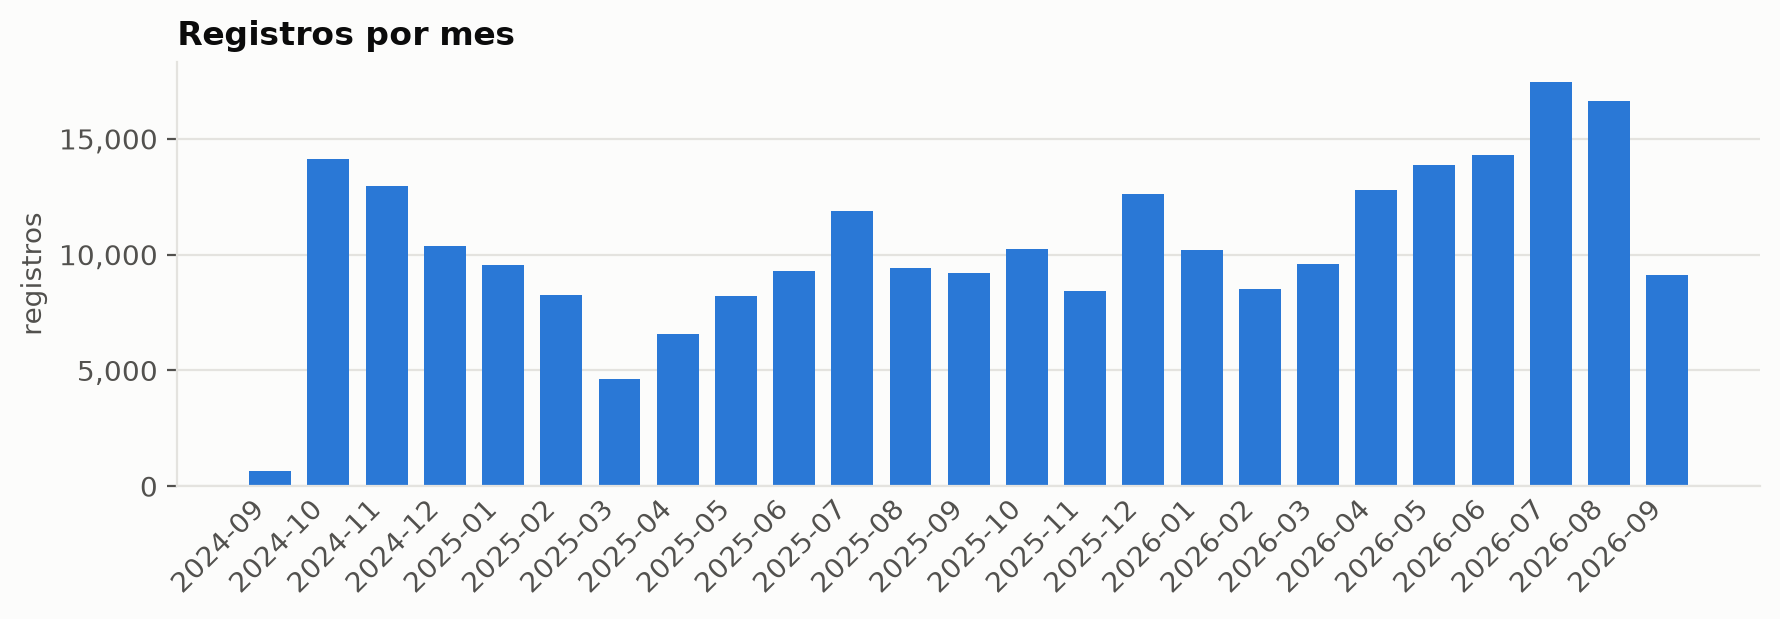

In [ ]:
by_month = mo.sql(
    f"""
    SELECT strftime(date_trunc('month', ts), '%Y-%m') AS mes, count(*) AS registros
    FROM bronze
    GROUP BY 1
    ORDER BY 1
    """,
    engine=con,
    output=False,
)
columns(by_month["mes"], by_month["registros"], "Registros por mes", "registros", rotate=45)

El archivo va en orden de llegada, pero no siempre en orden cronológico: a veces un
registro tiene una hora anterior a la del registro que lo precede. Contamos esos
retrocesos por tipo:

In [ ]:
out_of_order = mo.sql(
    f"""
    WITH o AS (
        SELECT kind, ts, lag(ts) OVER (ORDER BY record_no) AS anterior
        FROM bronze
    )
    SELECT
        kind AS tipo,
        count(*) AS retrocesos,
        count(*) FILTER (date_diff('second', ts, anterior) > 3600) AS de_mas_de_una_hora,
        round(median(date_diff('second', ts, anterior))) AS mediana_segundos
    FROM o
    WHERE ts < anterior
    GROUP BY kind
    ORDER BY retrocesos DESC
    """,
    engine=con
)

tipo,retrocesos,de_mas_de_una_hora,mediana_segundos
"""text""",114,16,243.0
"""attachment""",12,1,448.0
"""view_once""",4,0,265.0
"""system_notice""",1,1,29467.0


In [ ]:
big_jumps = mo.sql(
    f"""
    WITH o AS (
        SELECT record_no, kind, ts, lag(ts) OVER (ORDER BY record_no) AS anterior
        FROM bronze
    )
    SELECT
        record_no AS registro,
        kind AS tipo,
        anterior AS fecha_del_registro_anterior,
        ts AS fecha,
        round(date_diff('second', anterior, ts) / 86400, 1) AS salto_dias
    FROM o
    WHERE abs(date_diff('second', anterior, ts)) > 86400
    ORDER BY record_no
    """,
    engine=con
)

registro,tipo,fecha_del_registro_anterior,fecha,salto_dias
62381,"""group_notice""",2025-04-10 23:59:25,2025-09-28 15:24:09,170.6
62382,"""text""",2025-09-28 15:24:09,2025-04-10 23:59:46,-170.6
129749,"""system_notice""",2025-11-15 11:50:11,2025-11-18 18:24:04,3.3
129750,"""attachment""",2025-11-18 18:24:04,2025-11-15 13:46:26,-3.2


Casi todos los retrocesos son de segundos o minutos: mensajes que llegaron tarde al
celular o avisos como "fijó un mensaje". Los saltos de más de un día son casos
aislados: un registro fuera de lugar produce un salto hacia adelante y, en el registro
siguiente, uno hacia atrás del mismo tamaño. Aquí es un aviso del grupo (la llegada de
Meta AI) insertado meses antes de su fecha.

Conclusión: el orden del archivo se conserva como `message_id`, pero cualquier
análisis temporal debe ordenar por fecha y hora, no por posición.

## 6. Remitentes

In [ ]:
senders = mo.sql(
    f"""
    SELECT
        count(DISTINCT sender) AS remitentes,
        count(DISTINCT sender) FILTER (sender = getvariable('grupo')) AS el_grupo_como_remitente,
        count(DISTINCT sender) FILTER (sender <> getvariable('grupo')) AS personas,
        count(DISTINCT sender) FILTER (starts_with(sender, '~')) AS contactos_no_guardados,
        count(DISTINCT sender) FILTER (regexp_matches(sender, '^[~ {NNBSP}]*[+]?[0-9 -]+$'))
            AS remitentes_con_telefono
    FROM bronze
    """,
    engine=con
)

remitentes,el_grupo_como_remitente,personas,contactos_no_guardados,remitentes_con_telefono
43,1,42,14,0


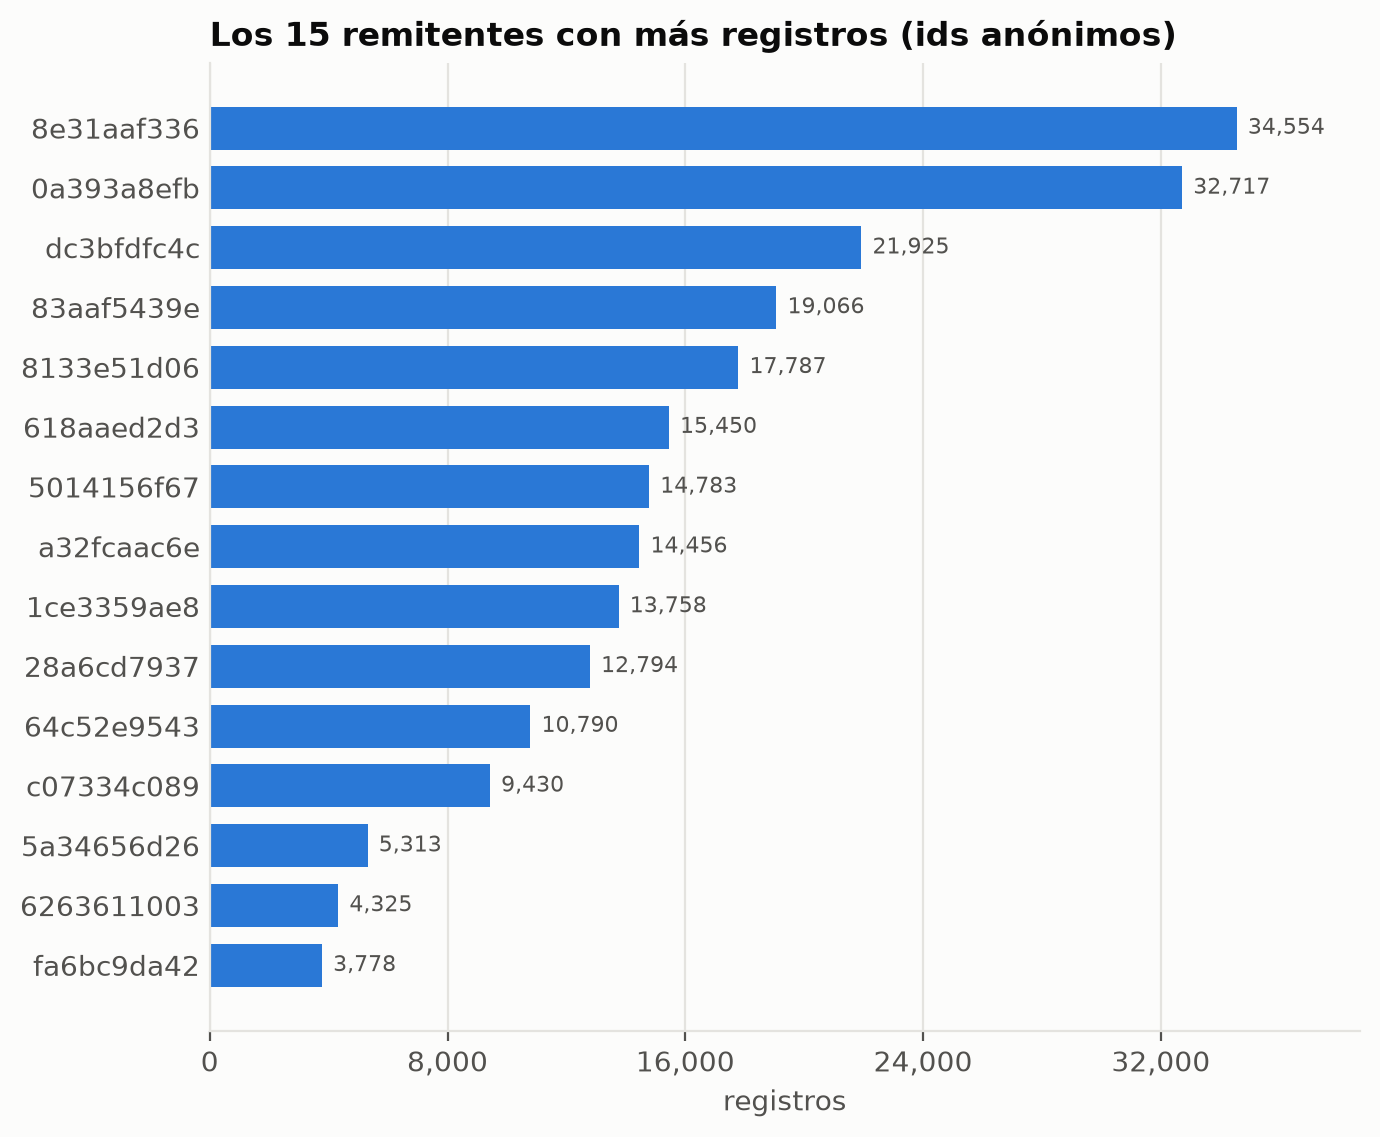

In [ ]:
by_sender = mo.sql(
    f"""
    SELECT anon(sender) AS remitente, registros
    FROM (
        SELECT sender, count(*) AS registros
        FROM bronze
        WHERE kind <> 'group_notice'
        GROUP BY sender
    )
    ORDER BY registros DESC
    LIMIT 15
    """,
    engine=con,
    output=False,
)
barh(
    by_sender["remitente"],
    by_sender["registros"],
    "Los 15 remitentes con más registros (ids anónimos)",
    "registros",
)

El nombre del grupo aparece como remitente: es quien "firma" los avisos del sistema
(cifrado de extremo a extremo, integración de Meta AI). No es una persona, así que se
tratará como aviso y no como usuario. Los nombres de las personas se ven con `~` y
U+202F cuando el celular no las tiene guardadas, y sin ellos cuando sí; `anon()`
normaliza ambas formas antes del hash.

Las **menciones** (`@Nombre`, con el nombre entre U+2068 y U+2069) también contienen
nombres reales, y algunas nombran a personas que nunca escriben en el grupo (como el
bot de Meta AI):

In [ ]:
mentions = mo.sql(
    f"""
    WITH m AS (
        SELECT unnest(regexp_extract_all(body, '@{FSI}([^{PDI}]*){PDI}', 1)) AS mentioned
        FROM bronze
    )
    SELECT
        count(*) AS menciones,
        count(DISTINCT anon(mentioned)) AS personas_mencionadas,
        count(DISTINCT anon(mentioned)) FILTER (
            anon(mentioned) NOT IN (SELECT DISTINCT anon(sender) FROM bronze)
        ) AS mencionadas_que_no_escriben,
        count(*) FILTER (regexp_matches(mentioned, '^[+]?[0-9 {NNBSP}-]+$')) AS menciones_a_telefonos
    FROM m
    """,
    engine=con
)

menciones,personas_mencionadas,mencionadas_que_no_escriben,menciones_a_telefonos
8446,42,1,0


## 7. Tipos de registro

Cada registro cae en uno de estos tipos (el código es el mismo que usará
`message_type` en los datos silver):

| Código | Qué es |
|---|---|
| `text` | mensaje de texto escrito por una persona |
| `attachment` | adjunto omitido al exportar (sticker, foto, audio, video, GIF, documento, contacto, nota de video), con o sin pie de foto |
| `poll` | encuesta: pregunta y opciones |
| `location` | ubicación compartida (trae coordenadas) |
| `view_once` | foto, video o audio de una sola vista: WhatsApp no lo exporta |
| `deleted` | mensaje borrado por su autor o por un admin |
| `unavailable` | mensaje que no llegó a descifrarse o no se puede mostrar |
| `system_notice` | aviso del sistema firmado por una persona (fijó, agregó, salió, cambió la descripción) |
| `group_notice` | aviso firmado por el grupo mismo (cifrado, Meta AI) |
| `empty` | encabezado con cuerpo vacío |

In [ ]:
kinds = mo.sql(
    f"""
    SELECT kind AS tipo, count(*) AS registros, round(100 * count(*) / sum(count(*)) OVER (), 2) AS pct
    FROM bronze
    GROUP BY kind
    ORDER BY registros DESC
    """,
    engine=con
)

tipo,registros,pct
"""text""",226829,87.57
"""attachment""",29522,11.4
"""view_once""",1393,0.54
"""deleted""",414,0.16
"""unavailable""",280,0.11
"""poll""",177,0.07
"""location""",160,0.06
"""system_notice""",118,0.05
"""empty""",110,0.04
"""group_notice""",11,0.0


Al exportar "sin archivos", cada adjunto se sustituye por un marcador en inglés. Las
fotos, los videos, los GIF y los documentos pueden traer pie de foto: texto escrito
por el usuario antes del marcador, que sí es contenido. Los stickers nunca lo traen.

In [ ]:
attachments = mo.sql(
    f"""
    SELECT
        regexp_extract(body, '{LRM}([A-Za-z ]+?) omitted', 1) AS adjunto,
        count(*) AS registros,
        count(*) FILTER (NOT starts_with(body, '{LRM}')) AS con_pie_de_foto
    FROM bronze
    WHERE kind = 'attachment'
    GROUP BY adjunto
    ORDER BY registros DESC
    """,
    engine=con
)

adjunto,registros,con_pie_de_foto
"""sticker""",21159,0
"""image""",7220,3232
"""audio""",409,0
"""video""",338,103
"""GIF""",287,25
"""video note""",48,0
"""document""",45,45
"""Contact card""",16,0


Rasgos del texto que importan para el parseo y el análisis (sobre mensajes de texto y
pies de foto):

In [ ]:
text_traits = mo.sql(
    f"""
    SELECT
        count(*) AS registros,
        count(*) FILTER (contains(body, '<This message was edited>')) AS editados,
        count(*) FILTER (contains(body, chr(10))) AS con_varias_lineas,
        max(len(string_split(body, chr(10)))) AS max_lineas,
        count(*) FILTER (regexp_matches(body, 'https?://')) AS con_url,
        count(*) FILTER (contains(body, '@{FSI}')) AS con_mencion,
        median(length(body)) FILTER (kind = 'text') AS mediana_caracteres_texto
    FROM bronze
    WHERE kind IN ('text', 'attachment')
    """,
    engine=con
)

registros,editados,con_varias_lineas,max_lineas,con_url,con_mencion,mediana_caracteres_texto
256351,1938,751,135,739,7767,19.0


Los mensajes editados llevan al final el sufijo `<This message was edited>` (precedido
de U+200E): hay que quitarlo del texto (si no, "message" y "edited" contarían como
palabras) y guardarlo como un indicador.

## 8. Avisos del sistema

Los avisos tienen nombres reales dentro del texto ("X added Y", "deleted by admin X").
Se muestran por patrón, escritos a mano, nunca con el texto original:

In [ ]:
notices = mo.sql(
    f"""
    SELECT
        kind AS tipo,
        CASE
            WHEN contains(body, 'Meta AI') THEN '... Meta AI ...'
            WHEN regexp_matches(body, ' pinned a message$') THEN '<persona> pinned a message'
            WHEN regexp_matches(body, ' changed the group description$') THEN '<persona> changed the group description'
            WHEN contains(body, ' changed the group name') THEN '<persona> changed the group name to "<nombre>"'
            WHEN regexp_matches(body, ' was added$') THEN '<persona> was added'
            WHEN contains(body, ' added ') THEN '<persona> added <persona>'
            WHEN contains(body, ' removed ') THEN '<persona> removed <persona>'
            WHEN regexp_matches(body, ' left$') THEN '<persona> left'
            WHEN contains(body, ' joined ') THEN '<persona> joined using the invite link'
            WHEN regexp_matches(body, 'admin approval|changed the settings') THEN '<persona> changed the group settings'
            WHEN contains(body, 'end-to-end encrypted') THEN 'Messages and calls are end-to-end encrypted...'
            WHEN contains(body, 'by admin') THEN 'This message was deleted by admin <persona>.'
            WHEN kind = 'deleted' THEN 'This message was deleted.'
            WHEN kind = 'location' THEN 'Location: https://maps.google.com/?q=<lat>,<lon>'
            ELSE 'otro'
        END AS patron,
        count(*) AS registros
    FROM bronze
    WHERE kind IN ('system_notice', 'group_notice', 'deleted', 'location')
    GROUP BY ALL
    ORDER BY tipo, registros DESC
    """,
    engine=con
)

tipo,patron,registros
"""deleted""","""This message was deleted.""",340
"""deleted""","""This message was deleted by admin <persona>.""",74
"""group_notice""","""... Meta AI ...""",6
"""group_notice""","""Messages and calls are end-to-end encrypted...""",5
"""location""","""Location: https://maps.google.com/?q=<lat>,<lon>""",160
"""system_notice""","""<persona> pinned a message""",36
"""system_notice""","""<persona> changed the group description""",35
"""system_notice""","""<persona> added <persona>""",12
"""system_notice""","""... Meta AI ...""",10
"""system_notice""","""<persona> left""",7


Las ubicaciones compartidas traen coordenadas exactas: se descartan por completo.

## 9. Qué conservamos y qué descartamos

Esta tabla es la especificación del job de anonimización (`make anonymize`). El job
deja tres archivos en `data/interim/<chat>/`:

- `bronze.parquet`: la tabla de este notebook (`record_no`, `timestamp`, `sender`,
  `body`, `kind`) **con nombres reales y el texto sin tocar**, para análisis manual en
  esta máquina. Como todo `data/`, nunca se sube a git.
- `members.parquet`: el alias (un animal de México) de cada `sender_id`, que
  se explica en `02_eda_silver`.
- `messages_anon.parquet`: la versión anonimizada, entrada de silver:

| Dato crudo | Decisión | Columna en `messages_anon` |
|---|---|---|
| Orden del registro en el archivo | se conserva | `message_id` |
| Fecha y hora (12 h, hora local) | se convierte a timestamp de 24 h, sin zona (hora local) | `timestamp` |
| Remitente | hash con sal (`anon`); vacío (`NULL`) en los avisos del grupo | `sender_id` |
| Tipo de registro | se conserva | `kind` |
| Texto, pie de foto y encuestas | se conservan con anonimización profunda | `body` |
| Marcador de adjunto (`sticker omitted`…) | se conserva: da el tipo de mensaje en silver | en `body` |
| Sufijo `<This message was edited>` | se conserva; en silver pasa a `is_edited` | en `body` |
| Una sola vista, eliminados, no disponibles, vacíos | se conserva el registro, sin cuerpo | `body` = `NULL` |
| Avisos del sistema y del grupo | se conserva el registro, **se descarta el texto** (trae nombres) | `body` = `NULL` |
| Ubicaciones | se conserva el registro, **se descartan las coordenadas** | `body` = `NULL` |
| Marcas invisibles U+200E, U+2068/9, U+202F | se conservan en interim; silver las limpia (U+200D se queda: es parte de los emojis) | en `body` |
| Nombres reales de remitentes y mencionados | solo en `raw/` y `bronze.parquet`, **nunca** en `messages_anon`, silver, notebooks ni git | — |

La anonimización profunda del texto reemplaza, en este orden:

| En el texto | Queda como |
|---|---|
| Mención `@Nombre` | `@[id]` (el id del mencionado; `@Meta AI` se deja porque es un bot) |
| URL | `[url:dominio]` (el resto puede traer usuarios o identificadores) |
| Correo | `[correo]` |
| Número de 8 dígitos o más: teléfono, cuenta, tarjeta, folio (no fechas ni rangos de años) | `[numero]` |
| Nombre o palabra de nombre de un miembro, sin importar mayúsculas, acentos ni letras decoradas | `[id]`, o `[nombre]` si la comparten varios miembros |

Queda un riesgo: apodos que no forman parte del nombre de contacto de nadie. La
verificación `make leak-check` busca todos los nombres reales en `messages_anon`,
silver, los notebooks exportados y las referencias, y falla si encuentra alguno.

Lo que queda para el EDA silver (`02_eda_silver`): definir los tipos de mensaje, qué
cuenta como palabra, emojis, stop words, adjetivos y los alias de los miembros.

## 10. El job produce lo mismo que este notebook

El parseo del job (`wasap_group_analyzer/parsing.py`) es el SQL de este notebook.
Si ya se corrió `make anonymize`, comparamos las dos tablas fila por fila:

In [ ]:
job_bronze = dirs["interim"] / "bronze.parquet"
mo.stop(
    not job_bronze.exists(),
    note("Todavía no existe `bronze.parquet`: corre `make anonymize` y vuelve a ejecutar."),
)

In [ ]:
job_check = mo.sql(
    f"""
    WITH job AS (SELECT * FROM read_parquet('{job_bronze}'))
    SELECT
        (SELECT count(*) FROM bronze) AS registros_notebook,
        (SELECT count(*) FROM job) AS registros_job,
        (SELECT count(*) FROM (
            SELECT record_no, ts, sender, body, kind FROM bronze
            EXCEPT
            SELECT record_no, timestamp, sender, body, kind FROM job
        )) AS filas_distintas
    """,
    engine=con
)

registros_notebook,registros_job,filas_distintas
259014,259014,0
